In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print(X.head())

Dataset Shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst 

In [3]:
print(X.info())
print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nTarget Classes:")
print(y.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [5]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [6]:
y_pred_dt = dt_model.predict(X_test)

In [7]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9210526315789473

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
y_pred_rf = rf_model.predict(X_test)

In [10]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [11]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

print(comparison)

           Model  Accuracy
0  Decision Tree  0.921053
1  Random Forest  0.956140


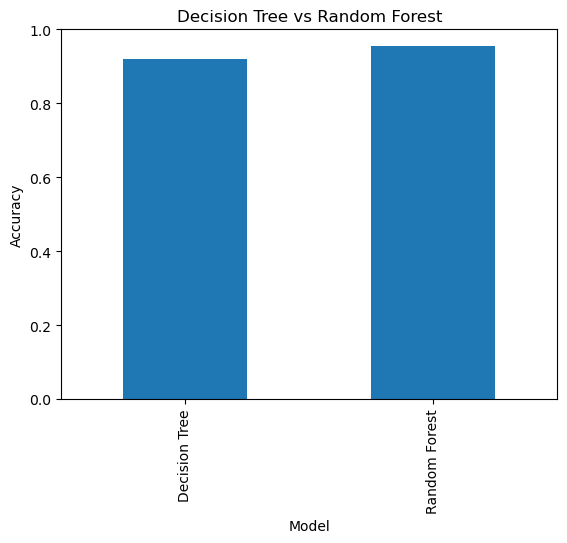

In [12]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Decision Tree vs Random Forest")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [13]:
cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm)

Random Forest Confusion Matrix:
[[39  3]
 [ 2 70]]


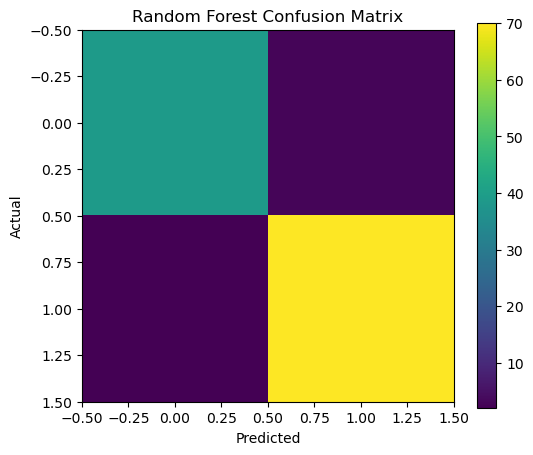

In [14]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [15]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


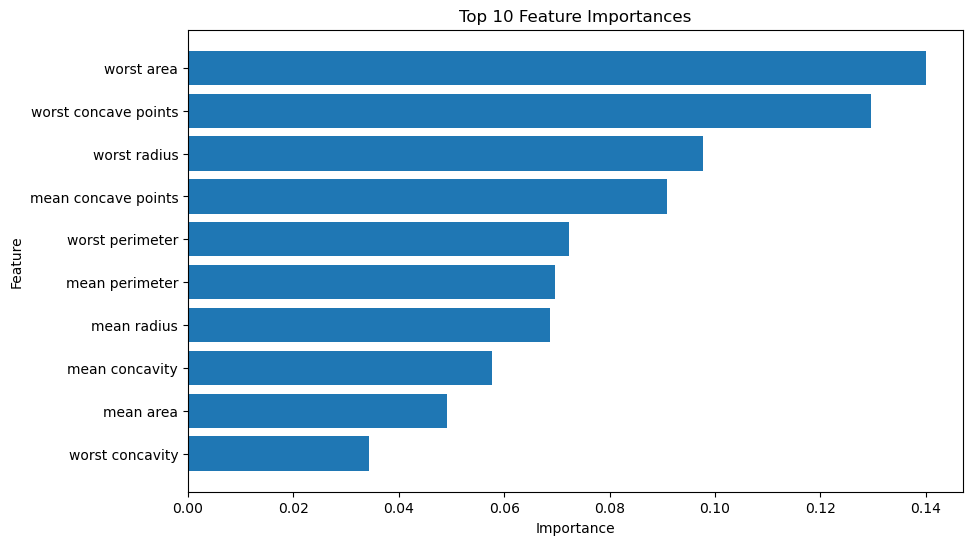

In [16]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [17]:
estimators = [10, 50, 100, 150, 200]
scores = []

for n in estimators:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

results = pd.DataFrame({
    "n_estimators": estimators,
    "Accuracy": scores
})

print(results)

   n_estimators  Accuracy
0            10  0.938596
1            50  0.956140
2           100  0.956140
3           150  0.956140
4           200  0.956140


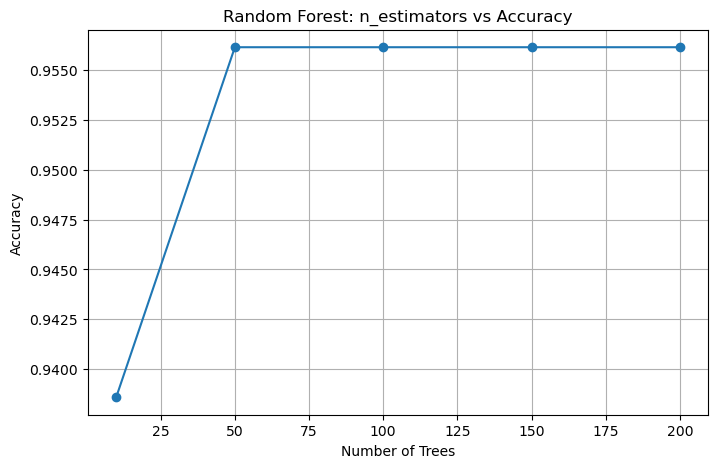

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["n_estimators"],
    results["Accuracy"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: n_estimators vs Accuracy")
plt.grid(True)

plt.show()

In [19]:
print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("Random Forest Accuracy:", round(rf_accuracy, 4))

if rf_accuracy > dt_accuracy:
    print("Random Forest performed better than the Decision Tree.")
elif rf_accuracy < dt_accuracy:
    print("Decision Tree performed better than Random Forest.")
else:
    print("Both models achieved the same accuracy.")

Decision Tree Accuracy: 0.9211
Random Forest Accuracy: 0.9561
Random Forest performed better than the Decision Tree.
